<a href="https://colab.research.google.com/github/samuelrossiello/data-analytics-portfolio/blob/main/projects/construction_bid_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Construction Bid Optimizer
## Portfolio Project | Linear Programming & Optimization

### Business Problem
New York City construction contracts awarded to general contractors
typically include Minority and Women Owned Business Enterprise (MWBE)
requirements — mandating that a fixed percentage of total subcontract
value be awarded to certified MBE and WBE firms. Meeting these goals
while minimizing total buyout cost is a complex multi-constraint
optimization problem that cannot be solved optimally by simple greedy
selection strategies.

### Objective
Build a linear programming model that identifies the optimal combination
of subcontractor awards across 10 major trades — minimizing total buyout
cost while meeting fixed MBE and WBE dollar targets. Compare the optimized
solution against two alternative strategies to quantify the business value
of mathematical optimization over manual selection approaches.

### Key Findings
- **The optimizer saved 2,358,596 vs the greedy MWBE strategy** while
  maintaining full compliance with all MWBE requirements
- **Greedy sequential selection is suboptimal** — filling MBE first then
  WBE produces a higher total cost than simultaneous multi-constraint
  optimization
- **Strategic MWBE allocation outperforms minimal compliance** — the
  optimizer concentrated WBE spend in the Concrete trade (31.7M) to
  satisfy the WBE goal in a single award, freeing other trades to select
  cheaper Non-MWBE bidders
- **The optimizer achieved 22.2% MBE and 23.3% WBE** — both above minimum
  requirements — at a lower total cost than the greedy approach which
  achieved 25.6% MBE and 10.1% WBE

### Scenario Comparison

| Scenario | Total Cost | Savings vs Budget | MBE % | WBE % | Compliant |
|---|---|---|---|---|---|
| Greedy Lowest Bid | 128,259,032 | 8,240,968 | 0.0% | 0.0% | NO |
| Greedy Lowest MWBE | 133,980,524 | 2,519,476 | 25.6% | 10.1% | YES |
| Optimized (PuLP) | 131,621,927 | 4,878,073 | 22.2% | 23.3% | YES |

**Scenario 1 — Greedy Lowest Bid:** Selects the cheapest bid per trade
with no MWBE consideration. Produces the lowest possible buyout cost
but fails both MWBE goals entirely — unusable in practice due to
contract compliance requirements. Beyond financial penalties,
non-compliance carries significant reputational risk for a general
contractor dependent on public work — jeopardizing future bid
eligibility and relationships with city agencies.

**Scenario 2 — Greedy Lowest MWBE:** Starts with cheapest bids then
sequentially swaps trades to MWBE until goals are met — filling MBE
first then WBE. Meets compliance but overspends on MBE at 25.6%
when only 20% was required.

**Scenario 3 — Optimized (PuLP):** Simultaneously optimizes all trade
awards against both MWBE goals using linear programming — finding the
globally optimal solution no greedy approach can guarantee. Saves
2,358,596 vs Scenario 2 while maintaining full compliance.

### Technical Approach
- **Dataset:** 60 synthetic bids across 10 major NYC construction trades
  (6 bidders per trade — 3 Non-MWBE, 1 MBE only, 1 WBE only,
  1 dual certified MWBE)
- **Base budget:** 136,500,000 (500,000 GSF x 273/GSF across 10 trades)
- **MWBE goals:** MBE >= 20% of base budget (27,300,000),
  WBE >= 10% of base budget (13,650,000)
- **Optimization:** PuLP Linear Programming with 70 binary decision
  variables and 22 constraints
- **Key constraint:** Dual certified MWBE firms can be allocated to
  either MBE or WBE bucket but not both simultaneously

### Tools Used
Python, Pandas, PuLP, Matplotlib, Google Colab, GitHub

### Limitations & Next Steps

#### Current Limitations
- **Synthetic bid data:** Model was tested on synthetic bids calibrated
  to real NYC construction market rates. Production implementation would
  use actual subcontractor bids from the estimating system
- **Direct award only:** Model assumes all MWBE credit comes from direct
  subcontract awards. In practice, subcontractors may allocate a portion
  of their contract to MWBE sub-tier contractors or suppliers — a mechanism
  that would allow partial MWBE credit and would require a more complex
  multi-level optimization approach
- **Fixed bidder pool:** Model assumes a fixed set of 6 bidders per trade.
  Real projects may have more bidders requiring the model to scale
  accordingly

#### Production Roadmap
- Integrate with estimating system to pull real subcontractor bids
  automatically
- Extend model to handle sub-tier MWBE participation credits
- Build a Streamlit interactive dashboard allowing estimators to lock
  in preferred subcontractors based on relationship history — the model
  reoptimizes remaining trades automatically and displays the cost
  premium of each preference decision
  subcontractor based on relationship history — for example forcing
  a specific award on a given trade — and automatically reoptimize
  the remaining trades around that fixed selection
- Extend to handle multiple simultaneous MWBE goal tiers (e.g. federal,
  state, and city requirements on the same project)
- Add scenario analysis showing how total buyout cost changes when
  different subcontractors are locked in by the estimating team

## Section 1: Imports and Setup

### Overview
All required libraries are imported and a random seed is set to ensure
reproducibility across all bid generation and optimization steps.

### Libraries
- **pandas, numpy:** Data manipulation and numerical computation
- **matplotlib, seaborn:** Data visualization
- **itertools.product:** Generates combinations for scenario comparison
- **pulp:** Linear programming optimization library — used to formulate
  and solve the MWBE buyout optimization problem
- **warnings:** Suppresses non-critical warnings for clean output

### Reproducibility
`np.random.seed(42)` ensures that all random operations — particularly
bid amount generation — produce identical results every time the
notebook is run, making the analysis fully reproducible.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product
import pulp
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
print("Libraries loaded successfully!")

Libraries loaded successfully!


## Section 2: Project Characteristics

### Overview
The core parameters of the project are defined here — trades, base costs,
project size, MWBE goals, and fixed dollar targets. These values drive
both the bid generation and the optimization constraints.

### Project Parameters
- **GSF:** 500,000 gross square feet
- **Base budget:** 136,500,000 (sum of base costs per trade x GSF)
- **MBE goal:** 20% of base budget — fixed target of 27,300,000
- **WBE goal:** 10% of base budget — fixed target of 13,650,000

### Base Costs per Trade
Unit costs per GSF calibrated to real NYC construction market rates:

| Trade | Cost per GSF |
|---|---|
| Concrete | 63 |
| Masonry | 27 |
| Steel | 18 |
| Carpentry | 33 |
| Roofing | 10 |
| Plumbing | 27 |
| HVAC | 30 |
| Electrical | 34 |
| Elevators | 7 |
| Finishes | 24 |

### Bidder Certification Structure
Each trade has exactly 6 bidders with the following certification
distribution — identical across all trades:
- 3 Non-MWBE bidders
- 1 MBE only bidder
- 1 WBE only bidder
- 1 dual certified MWBE bidder

### Design Decision
MWBE targets are fixed dollar amounts based on the base budget — not
percentages of actual buyout spend. This reflects the real world business
rule where MWBE goals are set by the funding agency at contract award
and do not change based on how the GC manages its subcontract buyouts.
Every dollar saved on buyouts below the base budget represents additional
profit for the general contractor.

In [3]:
# Project characteristics
trades = [
    "Concrete", "Masonry", "Steel", "Carpentry", "Roofing",
    "Plumbing", "HVAC", "Electrical", "Elevators", "Finishes"
]

base_costs = {
    "Concrete": 63, "Masonry": 27, "Steel": 18, "Carpentry": 33,
    "Roofing": 10, "Plumbing": 27, "HVAC": 30, "Electrical": 34,
    "Elevators": 7, "Finishes": 24
}

gsf = 500000
mbe_goal = 0.20
wbe_goal = 0.10

# Certification types per trade (same structure for every trade)
cert_types = [
    "Non-MWBE", "Non-MWBE", "Non-MWBE",
    "MBE", "WBE", "MWBE"
]

# Fixed MWBE targets based on base budget
total_budget = sum(base_costs.values()) * gsf
mbe_target = total_budget * mbe_goal
wbe_target = total_budget * wbe_goal

print("Project characteristics defined!")
print(f"Trades: {len(trades)}")
print(f"GSF: {gsf:,}")
print(f"Total base budget: ${total_budget:,}")
print(f"MBE target: ${mbe_target:,} ({mbe_goal*100:.0f}% of base budget)")
print(f"WBE target: ${wbe_target:,} ({wbe_goal*100:.0f}% of base budget)")

Project characteristics defined!
Trades: 10
GSF: 500,000
Total base budget: $136,500,000
MBE target: $27,300,000.0 (20% of base budget)
WBE target: $13,650,000.0 (10% of base budget)


## Section 3: Bid Generation

### Overview
A synthetic dataset of 60 subcontractor bids is generated — 6 bidders
per trade across 10 major trades. Bid amounts are calibrated to real
NYC construction market rates with realistic competitive variation and
MWBE price premiums.

### Pricing Structure
Each bid is calculated from the trade base cost with two layers of
variation:

**Non-MWBE bidders:**
- Base cost x random variation of +/- 10%
- Simulates competitive bidding around market rate

**MBE and WBE only bidders:**
- Base cost x +/- 10% variation x 8-12% MWBE premium
- Reflects higher demand and typically smaller firm size

**Dual certified MWBE bidders:**
- Base cost x +/- 10% variation x 10-15% MWBE premium
- Slightly higher premium reflecting dual certification
  and highest demand among MWBE subcontractors

### Bidder ID Convention
Bidder IDs are generated from the first 4 characters of the trade name
plus a sequential number — for example CONC-1 through CONC-6 for
Concrete. This ensures unique identifiable IDs across all trades
including Electrical (ELEC) and Elevators (ELEV) which share the
same first three characters.

### Key Observation
MWBE bids are consistently higher than Non-MWBE bids within each
trade — this price premium is what makes MWBE compliance a genuine
cost optimization challenge rather than a trivial selection problem.

In [4]:
def generate_bids():
    rows = []
    for trade in trades:
        base = base_costs[trade] * gsf
        for i, cert in enumerate(cert_types):
            # Apply price variation and MWBE premium
            if cert == "Non-MWBE":
                price = base * np.random.uniform(0.90, 1.10)
            elif cert == "MBE":
                price = base * np.random.uniform(0.90, 1.10) * np.random.uniform(1.08, 1.12)
            elif cert == "WBE":
                price = base * np.random.uniform(0.90, 1.10) * np.random.uniform(1.08, 1.12)
            else:  # MWBE dual certified
                price = base * np.random.uniform(0.90, 1.10) * np.random.uniform(1.10, 1.15)

            rows.append({
                "trade": trade,
                "bidder_id": f"{trade[:4].upper()}-{i+1}",
                "certification": cert,
                "bid_amount": round(price, 2)
            })

    return pd.DataFrame(rows)

df_bids = generate_bids()

print(f"Dataset shape: {df_bids.shape}")
print(f"\nBid data:")
print(df_bids.to_string(index=False))

Dataset shape: (60, 4)

Bid data:
     trade bidder_id certification  bid_amount
  Concrete    CONC-1      Non-MWBE 30709602.75
  Concrete    CONC-2      Non-MWBE 34339500.13
  Concrete    CONC-3      Non-MWBE 32961561.83
  Concrete    CONC-4           MBE 34891734.74
  Concrete    CONC-5           WBE 31747536.84
  Concrete    CONC-6          MWBE 38203692.74
   Masonry    MASO-1      Non-MWBE 14061795.96
   Masonry    MASO-2      Non-MWBE 12205578.13
   Masonry    MASO-3      Non-MWBE 14768756.60
   Masonry    MASO-4           MBE 15671689.64
   Masonry    MASO-5           WBE 13744937.73
   Masonry    MASO-6          MWBE 14608942.16
     Steel    STEE-1      Non-MWBE  8877501.03
     Steel    STEE-2      Non-MWBE  8624212.45
     Steel    STEE-3      Non-MWBE  9201335.21
     Steel    STEE-4           MBE  9116765.10
     Steel    STEE-5           WBE  9620004.34
     Steel    STEE-6          MWBE 10559626.40
 Carpentry    CARP-1      Non-MWBE 16546973.65
 Carpentry    CARP-2      

## Section 4: Optimization Problem Setup — Decision Variables

### Overview
The PuLP optimization problem is initialized and 70 binary decision
variables are created — one for each possible subcontractor selection
decision. These variables are what PuLP will set to 0 or 1 when finding
the optimal solution.

### Problem Initialization
`pulp.LpProblem("MWBE_Buyout_Optimizer", pulp.LpMinimize)` creates a
new optimization problem telling PuLP we want to minimize our objective
— total buyout cost. Think of this as opening a blank mathematical
workspace that we build up piece by piece.

### Decision Variable Structure
Two types of decision variables are created:

**Standard variables (50 total) — one per bid:**
Created for all Non-MWBE, MBE only, and WBE only bids. Each variable
is binary — 0 means not selected, 1 means selected and awarded.

**Dual certified MWBE variables (20 total) — two per bid:**
Each dual certified MWBE bidder gets two variables:
- x_mbe — selected AND allocated to the MBE bucket
- x_wbe — selected AND allocated to the WBE bucket

Two variables are required because a dual certified firm can count
toward either the MBE or WBE goal but not both — PuLP must decide
which bucket is optimal. Constraint 2 ensures only one of these
can equal 1 at a time.

### Variable Naming
PuLP variable names use underscores instead of hyphens —
`.replace("-", "_")` handles this conversion. For example:
- Dictionary key: ("CONC-1", "Concrete") — how we reference the variable in code
- PuLP internal name: x_CONC_1_Concrete — how PuLP references it in the solver

### Variable Count
- 50 standard variables (5 bidders x 10 trades)
- 10 MBE bucket variables (1 dual certified x 10 trades)
- 10 WBE bucket variables (1 dual certified x 10 trades)
- **70 total decision variables**

In [5]:
# Initialize the optimization problem
# LpMinimize tells PuLP we want to minimize the objective (total buyout cost)
prob = pulp.LpProblem("MWBE_Buyout_Optimizer", pulp.LpMinimize)

# ---- DECISION VARIABLES ----
# For each bid, create a binary variable (0 = not selected, 1 = selected)
# Non-MWBE, MBE only, and WBE only bids — one variable per bid
# .replace("-","_") converts hyphens to underscores in PuLP's internal variable name
x = {}
for _, row in df_bids.iterrows():
    if row["certification"] != "MWBE":
        x[row["bidder_id"], row["trade"]] = pulp.LpVariable(
            f"x_{row['bidder_id']}_{row['trade']}".replace("-", "_"),
            cat="Binary"  # variable can only be 0 or 1
        )

# Dual certified MWBE bids — two variables per bid
# x_mbe = selected AND allocated to MBE bucket
# x_wbe = selected AND allocated to WBE bucket
# Constraint 2 ensures only one can be 1 at a time
x_mbe = {}
x_wbe = {}
for _, row in df_bids[df_bids["certification"] == "MWBE"].iterrows():
    x_mbe[row["bidder_id"], row["trade"]] = pulp.LpVariable(
        f"xmbe_{row['bidder_id']}_{row['trade']}".replace("-", "_"),
        cat="Binary"
    )
    x_wbe[row["bidder_id"], row["trade"]] = pulp.LpVariable(
        f"xwbe_{row['bidder_id']}_{row['trade']}".replace("-", "_"),
        cat="Binary"
    )

print("Decision variables created!")
print(f"Standard variables (Non-MWBE, MBE only, WBE only): {len(x)}")
print(f"Dual MWBE — MBE bucket variables: {len(x_mbe)}")
print(f"Dual MWBE — WBE bucket variables: {len(x_wbe)}")
print(f"Total decision variables: {len(x) + len(x_mbe) + len(x_wbe)}")

Decision variables created!
Standard variables (Non-MWBE, MBE only, WBE only): 50
Dual MWBE — MBE bucket variables: 10
Dual MWBE — WBE bucket variables: 10
Total decision variables: 70


## Section 5: Objective Function

### Overview
The objective function defines what PuLP is trying to minimize —
total buyout cost across all 10 selected subcontractors. This is
the mathematical expression PuLP will minimize subject to the
constraints defined in Section 6.

### How It Works
For every bid in the dataset, the bid amount is multiplied by its
decision variable:
- If selected (variable = 1) → full bid amount added to total cost
- If not selected (variable = 0) → nothing added (bid amount x 0 = 0)

PuLP sums all of these terms and finds the combination of 0s and 1s
that produces the smallest possible total.

### Two Components

**Standard bids (Non-MWBE, MBE only, WBE only):**
One term per bid — straightforward multiplication of bid amount
by its single decision variable.

**Dual certified MWBE bids:**
Two terms per bid — bid amount multiplied by both x_mbe and x_wbe
variables. The cost is identical regardless of which bucket the
bidder is allocated to. Constraint 2 ensures only one of these
terms can be non-zero — so the dual certified bidder's cost is
counted exactly once if selected.

### Key Insight
The objective function alone does not enforce any MWBE requirements —
left unconstrained PuLP would simply select the cheapest bid for
every trade (Scenario 1). The constraints in Section 6 are what
force the optimizer to find the minimum cost solution that also
meets both MWBE goals.

In [6]:
# ---- OBJECTIVE FUNCTION ----
# Minimize total buyout cost across all selected subcontractors

prob += pulp.lpSum([
    # Standard bids (Non-MWBE, MBE only, WBE only)
    # bid_amount × variable — if selected (1) adds full cost, if not (0) adds nothing
    row["bid_amount"] * x[row["bidder_id"], row["trade"]]
    for _, row in df_bids[df_bids["certification"] != "MWBE"].iterrows()
] + [
    # Dual certified MWBE bids — cost is same regardless of which bucket
    # Only one of x_mbe or x_wbe can be 1 (enforced by Constraint 2)
    # So at most one of these terms will contribute to the total
    row["bid_amount"] * x_mbe[row["bidder_id"], row["trade"]] +
    row["bid_amount"] * x_wbe[row["bidder_id"], row["trade"]]
    for _, row in df_bids[df_bids["certification"] == "MWBE"].iterrows()
])

print("Objective function added!")
print("Objective: Minimize total buyout cost")

Objective function added!
Objective: Minimize total buyout cost


## Section 6: Optimization Constraints

### Overview
Four constraints are added to the optimization problem — defining the
business rules that every valid solution must satisfy. PuLP will only
consider solutions that meet all four constraints simultaneously.

### Constraint 1: Exactly One Bidder Per Trade (10 constraints)
For each trade all decision variables must sum to exactly 1 — ensuring
exactly one subcontractor is awarded each trade. No trade can be
unawarded and no trade can have multiple winners.

For dual certified bidders x_mbe and x_wbe together represent selection
— if either equals 1 the bidder is selected. Combined with Constraint 2
this ensures the dual certified bidder can only be selected once and
allocated to one bucket.

### Constraint 2: Dual Certified MWBE — One Bucket Only (10 constraints)
For each dual certified bidder x_mbe + x_wbe must be less than or equal
to 1 — preventing allocation to both buckets simultaneously.

Valid states for each dual certified bidder:
- (0, 0) — not selected
- (1, 0) — selected, allocated to MBE bucket
- (0, 1) — selected, allocated to WBE bucket
- (1, 1) — INVALID, violates constraint

### Constraint 3: MBE Fixed Dollar Target (1 constraint)
The sum of all selected MBE only bids plus any dual certified bids
allocated to the MBbe bucket must be at least 27,300,000 — 20% of
the base budget.

This is a fixed dollar target set by the funding agency at contract
award — it does not change based on total buyout spend. Dual certified
bids allocated to the WBE bucket are explicitly excluded from this
calculation.

### Constraint 4: WBE Fixed Dollar Target (1 constraint)
The sum of all selected WBE only bids plus any dual certified bids
allocated to the WBE bucket must be at least 13,650,000 — 10% of
the base budget.

Identical structure to Constraint 3 but for WBE. Dual certified bids
allocated to the MBE bucket are explicitly excluded from this
calculation.

### Total Constraints: 22
| Constraint Type | Count |
|---|---|
| One bidder per trade | 10 |
| One bucket per dual certified bidder | 10 |
| MBE fixed dollar target | 1 |
| WBE fixed dollar target | 1 |
| **Total** | **22** |

### Why These Constraints Matter
Without constraints PuLP would simply select the cheapest bid for
every trade — producing Scenario 1 (non-compliant). The constraints
force the optimizer to find the minimum cost solution that also
satisfies all MWBE business rules — a problem too complex for manual
estimation across 70 decision variables and 22 constraints simultaneously.

In [7]:
# ---- CONSTRAINTS ----

# Constraint 1: Exactly one bidder selected per trade
# All decision variables for a given trade must sum to exactly 1
# Dual certified bidder counts as selected if either x_mbe or x_wbe = 1
for trade in trades:
    trade_bids = df_bids[df_bids["trade"] == trade]
    prob += pulp.lpSum([
        x[row["bidder_id"], row["trade"]]
        for _, row in trade_bids[trade_bids["certification"] != "MWBE"].iterrows()
    ] + [
        # x_mbe + x_wbe together represent whether dual certified bidder is selected
        x_mbe[row["bidder_id"], row["trade"]] +
        x_wbe[row["bidder_id"], row["trade"]]
        for _, row in trade_bids[trade_bids["certification"] == "MWBE"].iterrows()
    ]) == 1, f"one_bidder_{trade}"

# Constraint 2: Dual certified MWBE can only go in ONE bucket
# x_mbe + x_wbe <= 1 prevents both from being 1 simultaneously
# Valid states: (0,0) = not selected, (1,0) = MBE bucket, (0,1) = WBE bucket
for _, row in df_bids[df_bids["certification"] == "MWBE"].iterrows():
    prob += x_mbe[row["bidder_id"], row["trade"]] + \
            x_wbe[row["bidder_id"], row["trade"]] <= 1, \
            f"one_bucket_{row['bidder_id']}_{row['trade']}".replace("-", "_")

# Constraint 3: MBE fixed dollar target >= 20% of base budget ($27,300,000)
# Counts MBE only bids + dual certified bids allocated to MBE bucket
prob += pulp.lpSum([
    # MBE only bids — always count toward MBE goal if selected
    row["bid_amount"] * x[row["bidder_id"], row["trade"]]
    for _, row in df_bids[df_bids["certification"] == "MBE"].iterrows()
] + [
    # Dual certified bids — only count toward MBE if allocated to MBE bucket
    row["bid_amount"] * x_mbe[row["bidder_id"], row["trade"]]
    for _, row in df_bids[df_bids["certification"] == "MWBE"].iterrows()
]) >= mbe_target, "mbe_goal"

# Constraint 4: WBE fixed dollar target >= 10% of base budget ($13,650,000)
# Counts WBE only bids + dual certified bids allocated to WBE bucket
prob += pulp.lpSum([
    # WBE only bids — always count toward WBE goal if selected
    row["bid_amount"] * x[row["bidder_id"], row["trade"]]
    for _, row in df_bids[df_bids["certification"] == "WBE"].iterrows()
] + [
    # Dual certified bids — only count toward WBE if allocated to WBE bucket
    row["bid_amount"] * x_wbe[row["bidder_id"], row["trade"]]
    for _, row in df_bids[df_bids["certification"] == "MWBE"].iterrows()
]) >= wbe_target, "wbe_goal"

print("Constraints added!")
print(f"Total constraints: {len(prob.constraints)}")
print(prob)

Constraints added!
Total constraints: 22
MWBE_Buyout_Optimizer:
MINIMIZE
16546973.65*x_CARP_1_Carpentry + 16804968.08*x_CARP_2_Carpentry + 15003286.36*x_CARP_3_Carpentry + 18318256.52*x_CARP_4_Carpentry + 16841629.79*x_CARP_5_Carpentry + 30709602.75*x_CONC_1_Concrete + 34339500.13*x_CONC_2_Concrete + 32961561.83*x_CONC_3_Concrete + 34891734.74*x_CONC_4_Concrete + 31747536.84*x_CONC_5_Concrete + 16512961.31*x_ELEC_1_Electrical + 16255177.33*x_ELEC_2_Electrical + 17145166.68*x_ELEC_3_Electrical + 17547792.97*x_ELEC_4_Electrical + 17411730.7*x_ELEC_5_Electrical + 3153865.48*x_ELEV_1_Elevators + 3720823.0*x_ELEV_2_Elevators + 3644800.14*x_ELEV_3_Elevators + 4066052.81*x_ELEV_4_Elevators + 3503887.63*x_ELEV_5_Elevators + 12295915.5*x_FINI_1_Finishes + 11594155.26*x_FINI_2_Finishes + 10952540.04*x_FINI_3_Finishes + 12620253.49*x_FINI_4_Finishes + 13875219.97*x_FINI_5_Finishes + 15293699.94*x_HVAC_1_HVAC + 16265622.71*x_HVAC_2_HVAC + 13765477.51*x_HVAC_3_HVAC + 15240470.86*x_HVAC_4_HVAC + 158

## Section 7: Scenario 1 — Greedy Lowest Bid

### Overview
The first benchmark scenario simulates a naive estimator who selects
the cheapest available bid for every trade regardless of MWBE
certification status. This represents the theoretical cost floor —
the absolute minimum possible buyout cost with no MWBE considerations.

### Strategy
For each trade, filter all 6 bids and select the one with the lowest
bid amount. MWBE certification is completely ignored — the only
criteria is price.

### Result
- **Total buyout cost: 128,259,032** — cheapest possible outcome
- **Savings vs base budget: 8,240,968**
- **MBE spend: 0.0% — NON-COMPLIANT**
- **WBE spend: 0.0% — NON-COMPLIANT**

Every trade was awarded to a Non-MWBE subcontractor — confirming
that the cheapest bid in every trade happened to be Non-MWBE,
which is expected given the 8-15% MWBE price premium built into
the bid generation.

### Business Context
While Scenario 1 produces the highest savings vs base budget, it
is completely unusable in practice. NYC construction contracts with
MWBE requirements carry penalties for non-compliance including
potential contract termination, withheld payments, and disqualification
from future public work. Scenario 1 serves purely as a theoretical
lower bound on buyout cost.

### Role in Comparison
Scenario 1 establishes the cost of full MWBE non-compliance — the
gap between Scenario 1 and the compliant scenarios represents the
true cost of meeting MWBE requirements on this project.

In [8]:
# ---- SCENARIO 1: GREEDY LOWEST BID (ignores MWBE) ----
scenario1 = []
for trade in trades:
    trade_bids = df_bids[df_bids["trade"] == trade]
    lowest_bid = trade_bids.loc[trade_bids["bid_amount"].idxmin()]
    scenario1.append({
        "trade": lowest_bid["trade"],
        "bidder_id": lowest_bid["bidder_id"],
        "certification": lowest_bid["certification"],
        "bucket": "MBE" if lowest_bid["certification"] == "MBE"
                  else "WBE" if lowest_bid["certification"] == "WBE"
                  else "Non-MWBE",
        "bid_amount": lowest_bid["bid_amount"]
    })

df_scenario1 = pd.DataFrame(scenario1)
df_scenario1["trade"] = pd.Categorical(df_scenario1["trade"],
                                        categories=trades, ordered=True)
df_scenario1 = df_scenario1.sort_values("trade").reset_index(drop=True)

# Calculate totals
s1_total = df_scenario1["bid_amount"].sum()
s1_mbe = df_scenario1[df_scenario1["bucket"] == "MBE"]["bid_amount"].sum()
s1_wbe = df_scenario1[df_scenario1["bucket"] == "WBE"]["bid_amount"].sum()

print(f"{'='*65}")
print(f"SCENARIO 1: GREEDY LOWEST BID (ignores MWBE requirements)")
print(f"{'='*65}")
print(df_scenario1.to_string(index=False))
print(f"{'='*65}")
print(f"TOTAL BUYOUT COST:    ${s1_total:>15,.2f}")
print(f"BASE BUDGET:          ${total_budget:>15,.2f}")
print(f"SAVINGS:              ${total_budget - s1_total:>15,.2f}")
print(f"{'='*65}")
print(f"MBE SPEND:            ${s1_mbe:>15,.2f} ({s1_mbe/total_budget*100:.1f}% of base budget)")
print(f"WBE SPEND:            ${s1_wbe:>15,.2f} ({s1_wbe/total_budget*100:.1f}% of base budget)")
print(f"MBE GOAL MET:         {'YES ✓' if s1_mbe >= mbe_target else 'NO ✗'}")
print(f"WBE GOAL MET:         {'YES ✓' if s1_wbe >= wbe_target else 'NO ✗'}")
print(f"{'='*65}")

SCENARIO 1: GREEDY LOWEST BID (ignores MWBE requirements)
     trade bidder_id certification   bucket  bid_amount
  Concrete    CONC-1      Non-MWBE Non-MWBE 30709602.75
   Masonry    MASO-2      Non-MWBE Non-MWBE 12205578.13
     Steel    STEE-2      Non-MWBE Non-MWBE  8624212.45
 Carpentry    CARP-3      Non-MWBE Non-MWBE 15003286.36
   Roofing    ROOF-2      Non-MWBE Non-MWBE  4597672.11
  Plumbing    PLUM-2      Non-MWBE Non-MWBE 12991619.91
      HVAC    HVAC-3      Non-MWBE Non-MWBE 13765477.51
Electrical    ELEC-2      Non-MWBE Non-MWBE 16255177.33
 Elevators    ELEV-1      Non-MWBE Non-MWBE  3153865.48
  Finishes    FINI-3      Non-MWBE Non-MWBE 10952540.04
TOTAL BUYOUT COST:    $ 128,259,032.07
BASE BUDGET:          $ 136,500,000.00
SAVINGS:              $   8,240,967.93
MBE SPEND:            $           0.00 (0.0% of base budget)
WBE SPEND:            $           0.00 (0.0% of base budget)
MBE GOAL MET:         NO ✗
WBE GOAL MET:         NO ✗


## Section 8: Scenario 2 — Greedy Lowest MWBE

### Overview
The second benchmark scenario simulates how a human estimator would
typically approach MWBE compliance manually — starting with the
cheapest bids and sequentially swapping trades to MWBE certified
firms until each goal is met. This is the most realistic representation
of manual estimation practice.

### Strategy — Three Sequential Steps

**Step 1 — Start with cheapest bids:**
Identical to Scenario 1 — select the lowest bid for every trade
regardless of certification status.

**Step 2 — Fill MBE goal first:**
Check if MBE target of 27,300,000 is met. If not, loop through
trades one by one and swap to the cheapest available MBE or dual
certified MWBE bid until the target is satisfied — then stop.

**Step 3 — Fill WBE goal second:**
Check if WBE target of 13,650,000 is met. If not, loop through
remaining trades and swap to the cheapest available WBE or dual
certified MWBE bid — skipping any trade already swapped to MBE
in Step 2.

### Why This Is Suboptimal
The sequential nature of this approach creates two sources of
inefficiency:
- **MBE gets first pick** — the cheapest MWBE options are consumed
  by the MBE goal first, leaving WBE with more expensive alternatives
- **Trade order matters** — trades earlier in the list get considered
  first for swaps, regardless of which swap would be most cost effective
- **Goals treated independently** — the algorithm cannot see that
  a different allocation across both goals simultaneously would
  produce a lower total cost

### Result
- **Total buyout cost: 133,980,524** — compliant but inefficient
- **Savings vs base budget: 2,519,476**
- **MBE spend: 25.6% — overshoots 20% goal by 5.6 points**
- **WBE spend: 10.1% — barely meets 10% goal**

### Key Observation
Scenario 2 overspends on MBE by selecting the entire Concrete trade
(34,891,734) as its MBE award — a single large trade that satisfies
the MBE goal but at a higher cost than necessary. The optimizer
finds a smarter allocation that meets both goals at lower total cost
by considering all trades simultaneously rather than sequentially.

In [9]:
# ---- SCENARIO 2: GREEDY LOWEST MWBE ----
# Step 1 — Start with lowest bid per trade
scenario2 = []
for trade in trades:
    trade_bids = df_bids[df_bids["trade"] == trade]
    lowest_bid = trade_bids.loc[trade_bids["bid_amount"].idxmin()]
    scenario2.append({
        "trade": lowest_bid["trade"],
        "bidder_id": lowest_bid["bidder_id"],
        "certification": lowest_bid["certification"],
        "bucket": "MBE" if lowest_bid["certification"] == "MBE"
                  else "WBE" if lowest_bid["certification"] == "WBE"
                  else "Non-MWBE",
        "bid_amount": lowest_bid["bid_amount"]
    })

df_scenario2 = pd.DataFrame(scenario2)

# Step 2 — Check MBE goal and swap in cheapest MBE bid if needed
mbe_spend = df_scenario2[df_scenario2["bucket"] == "MBE"]["bid_amount"].sum()

if mbe_spend < mbe_target:
    for trade in trades:
        if mbe_spend >= mbe_target:
            break
        current = df_scenario2[df_scenario2["trade"] == trade].iloc[0]
        if current["bucket"] != "MBE":
            trade_bids = df_bids[df_bids["trade"] == trade]
            mbe_bids = trade_bids[trade_bids["certification"].isin(["MBE", "MWBE"])]
            if not mbe_bids.empty:
                cheapest_mbe = mbe_bids.loc[mbe_bids["bid_amount"].idxmin()]
                df_scenario2.loc[df_scenario2["trade"] == trade,
                                  ["bidder_id", "certification",
                                   "bucket", "bid_amount"]] = [
                    cheapest_mbe["bidder_id"],
                    cheapest_mbe["certification"],
                    "MBE",
                    cheapest_mbe["bid_amount"]
                ]
                mbe_spend = df_scenario2[df_scenario2["bucket"] == "MBE"]["bid_amount"].sum()

# Step 3 — Check WBE goal and swap in cheapest WBE bid if needed
wbe_spend = df_scenario2[df_scenario2["bucket"] == "WBE"]["bid_amount"].sum()

if wbe_spend < wbe_target:
    for trade in trades:
        if wbe_spend >= wbe_target:
            break
        current = df_scenario2[df_scenario2["trade"] == trade].iloc[0]
        if current["bucket"] != "WBE" and current["bucket"] != "MBE":
            trade_bids = df_bids[df_bids["trade"] == trade]
            wbe_bids = trade_bids[trade_bids["certification"].isin(["WBE", "MWBE"])]
            if not wbe_bids.empty:
                cheapest_wbe = wbe_bids.loc[wbe_bids["bid_amount"].idxmin()]
                df_scenario2.loc[df_scenario2["trade"] == trade,
                                  ["bidder_id", "certification",
                                   "bucket", "bid_amount"]] = [
                    cheapest_wbe["bidder_id"],
                    cheapest_wbe["certification"],
                    "WBE",
                    cheapest_wbe["bid_amount"]
                ]
                wbe_spend = df_scenario2[df_scenario2["bucket"] == "WBE"]["bid_amount"].sum()

# Sort and display results
df_scenario2["trade"] = pd.Categorical(df_scenario2["trade"],
                                        categories=trades, ordered=True)
df_scenario2 = df_scenario2.sort_values("trade").reset_index(drop=True)

s2_total = df_scenario2["bid_amount"].sum()
s2_mbe = df_scenario2[df_scenario2["bucket"] == "MBE"]["bid_amount"].sum()
s2_wbe = df_scenario2[df_scenario2["bucket"] == "WBE"]["bid_amount"].sum()

print(f"{'='*65}")
print(f"SCENARIO 2: GREEDY LOWEST MWBE")
print(f"{'='*65}")
print(df_scenario2.to_string(index=False))
print(f"{'='*65}")
print(f"TOTAL BUYOUT COST:    ${s2_total:>15,.2f}")
print(f"BASE BUDGET:          ${total_budget:>15,.2f}")
print(f"SAVINGS:              ${total_budget - s2_total:>15,.2f}")
print(f"{'='*65}")
print(f"MBE SPEND:            ${s2_mbe:>15,.2f} ({s2_mbe/total_budget*100:.1f}% of base budget)")
print(f"WBE SPEND:            ${s2_wbe:>15,.2f} ({s2_wbe/total_budget*100:.1f}% of base budget)")
print(f"MBE GOAL MET:         {'YES ✓' if s2_mbe >= mbe_target else 'NO ✗'}")
print(f"WBE GOAL MET:         {'YES ✓' if s2_wbe >= wbe_target else 'NO ✗'}")
print(f"{'='*65}")

SCENARIO 2: GREEDY LOWEST MWBE
     trade bidder_id certification   bucket  bid_amount
  Concrete    CONC-4           MBE      MBE 34891734.74
   Masonry    MASO-5           WBE      WBE 13744937.73
     Steel    STEE-2      Non-MWBE Non-MWBE  8624212.45
 Carpentry    CARP-3      Non-MWBE Non-MWBE 15003286.36
   Roofing    ROOF-2      Non-MWBE Non-MWBE  4597672.11
  Plumbing    PLUM-2      Non-MWBE Non-MWBE 12991619.91
      HVAC    HVAC-3      Non-MWBE Non-MWBE 13765477.51
Electrical    ELEC-2      Non-MWBE Non-MWBE 16255177.33
 Elevators    ELEV-1      Non-MWBE Non-MWBE  3153865.48
  Finishes    FINI-3      Non-MWBE Non-MWBE 10952540.04
TOTAL BUYOUT COST:    $ 133,980,523.66
BASE BUDGET:          $ 136,500,000.00
SAVINGS:              $   2,519,476.34
MBE SPEND:            $  34,891,734.74 (25.6% of base budget)
WBE SPEND:            $  13,744,937.73 (10.1% of base budget)
MBE GOAL MET:         YES ✓
WBE GOAL MET:         YES ✓


## Section 9: Scenario 3 — Optimized Buyout (PuLP)

### Overview
The optimization model is solved using PuLP's CBC solver — a free
open source linear programming solver bundled with PuLP. Unlike the
greedy scenarios, the optimizer considers all 70 decision variables
and both MWBE goals simultaneously, finding the globally optimal
solution in a single pass.

### How the Solver Works
`prob.solve(pulp.PULP_CBC_CMD(msg=0))` triggers the CBC solver which
uses a technique called branch and bound — systematically exploring
the solution space and pruning combinations that cannot improve on
the current best solution. This is far more efficient than brute
forcing all 9,765,625 possible combinations (5 choices per trade
across 10 trades).

`msg=0` suppresses the solver's verbose output for clean results.

### Extracting Results
After solving, each decision variable is checked:

**Standard bids:**
`pulp.value(var) == 1` identifies which standard bids were selected.
The bucket is set directly from the certification type.

**Dual certified MWBE bids:**
Both x_mbe and x_wbe are checked separately — if x_mbe = 1 the
bidder was allocated to the MBE bucket, if x_wbe = 1 they were
allocated to the WBE bucket. This reveals which bucket PuLP
determined was optimal for each dual certified firm.

### Result
- **Total buyout cost: 131,621,927 — optimal compliant solution**
- **Savings vs base budget: 4,878,073**
- **MBE spend: 22.2% — meets 20% goal with minimal overspend**
- **WBE spend: 23.3% — exceeds 10% goal**
- **Both goals met: YES**

### Key Finding
The optimizer concentrated the entire WBE requirement in the Concrete
trade by selecting CONC-5 (WBE certified) at 31,747,537 — satisfying
the full WBE goal in a single award. This freed all other trades to
select cheaper Non-MWBE bids, producing a lower total cost than the
greedy approach despite a higher WBE percentage.

This non-obvious allocation strategy — concentrating MWBE spend in
fewer larger trades rather than spreading it across many trades — is
exactly the kind of insight that mathematical optimization reveals
and manual estimation cannot reliably find.

In [10]:
# ---- SCENARIO 3: OPTIMIZED BUYOUT (PuLP Linear Programming) ----
# Uses mathematical optimization to find the minimum cost combination
# of subcontractor awards that meets both MBE and WBE goals simultaneously
# Unlike greedy approaches, considers all trades and both goals at once

# ---- SOLVE ----
prob.solve(pulp.PULP_CBC_CMD(msg=0))

# Check solution status
print(f"Status: {pulp.LpStatus[prob.status]}")
print(f"\nOptimal Total Buyout Cost: ${pulp.value(prob.objective):,.2f}")
print(f"Base Budget:               ${total_budget:,.2f}")
print(f"Savings vs Base Budget:    ${total_budget - pulp.value(prob.objective):,.2f}")

# ---- EXTRACT RESULTS ----
results = []

# Standard bids
for _, row in df_bids[df_bids["certification"] != "MWBE"].iterrows():
    var = x[row["bidder_id"], row["trade"]]
    if pulp.value(var) == 1:
        results.append({
            "trade": row["trade"],
            "bidder_id": row["bidder_id"],
            "certification": row["certification"],
            "bucket": row["certification"] if row["certification"] != "Non-MWBE" else "Non-MWBE",
            "bid_amount": row["bid_amount"]
        })

# Dual certified MWBE bids
for _, row in df_bids[df_bids["certification"] == "MWBE"].iterrows():
    mbe_val = pulp.value(x_mbe[row["bidder_id"], row["trade"]])
    wbe_val = pulp.value(x_wbe[row["bidder_id"], row["trade"]])
    if mbe_val == 1:
        results.append({
            "trade": row["trade"],
            "bidder_id": row["bidder_id"],
            "certification": row["certification"],
            "bucket": "MBE",
            "bid_amount": row["bid_amount"]
        })
    elif wbe_val == 1:
        results.append({
            "trade": row["trade"],
            "bidder_id": row["bidder_id"],
            "certification": row["certification"],
            "bucket": "WBE",
            "bid_amount": row["bid_amount"]
        })

# Convert to DataFrame and sort by trade order
df_results = pd.DataFrame(results)
df_results["trade"] = pd.Categorical(df_results["trade"],
                                      categories=trades, ordered=True)
df_results = df_results.sort_values("trade").reset_index(drop=True)

# Calculate MWBE totals
mbe_total = df_results[df_results["bucket"] == "MBE"]["bid_amount"].sum()
wbe_total = df_results[df_results["bucket"] == "WBE"]["bid_amount"].sum()
total_buyout = df_results["bid_amount"].sum()

print(f"{'='*65}")
print(f"SCENARIO 3: OPTIMIZED BUYOUT (PuLP Linear Programming)")
print(f"{'='*65}")
print(df_results.to_string(index=False))
print(f"{'='*65}")
print(f"TOTAL BUYOUT COST:    ${total_buyout:>15,.2f}")
print(f"BASE BUDGET:          ${total_budget:>15,.2f}")
print(f"SAVINGS:              ${total_budget - total_buyout:>15,.2f}")
print(f"{'='*65}")
print(f"MBE SPEND:            ${mbe_total:>15,.2f} ({mbe_total/total_budget*100:.1f}% of base budget)")
print(f"WBE SPEND:            ${wbe_total:>15,.2f} ({wbe_total/total_budget*100:.1f}% of base budget)")
print(f"MBE GOAL MET:         {'YES ✓' if mbe_total >= mbe_target else 'NO ✗'}")
print(f"WBE GOAL MET:         {'YES ✓' if wbe_total >= wbe_target else 'NO ✗'}")
print(f"{'='*65}")

Status: Optimal

Optimal Total Buyout Cost: $131,621,927.18
Base Budget:               $136,500,000.00
Savings vs Base Budget:    $4,878,072.82
SCENARIO 3: OPTIMIZED BUYOUT (PuLP Linear Programming)
     trade bidder_id certification   bucket  bid_amount
  Concrete    CONC-5           WBE      WBE 31747536.84
   Masonry    MASO-2      Non-MWBE Non-MWBE 12205578.13
     Steel    STEE-4           MBE      MBE  9116765.10
 Carpentry    CARP-3      Non-MWBE Non-MWBE 15003286.36
   Roofing    ROOF-2      Non-MWBE Non-MWBE  4597672.11
  Plumbing    PLUM-2      Non-MWBE Non-MWBE 12991619.91
      HVAC    HVAC-3      Non-MWBE Non-MWBE 13765477.51
Electrical    ELEC-4           MBE      MBE 17547792.97
 Elevators    ELEV-6          MWBE      MBE  3693658.21
  Finishes    FINI-3      Non-MWBE Non-MWBE 10952540.04
TOTAL BUYOUT COST:    $ 131,621,927.18
BASE BUDGET:          $ 136,500,000.00
SAVINGS:              $   4,878,072.82
MBE SPEND:            $  30,358,216.28 (22.2% of base budget)
WBE SP

## Section 10: Scenario Comparison Summary

### Overview
All three scenarios are compared side by side on total buyout cost,
savings vs base budget, and MWBE compliance — providing a clear
quantified business case for mathematical optimization over manual
selection strategies.

### Cost Comparison

| Scenario | Total Cost | Savings vs Budget |
|---|---|---|
| 1 — Greedy Lowest Bid | 128,259,032 | 8,240,968 |
| 2 — Greedy Lowest MWBE | 133,980,524 | 2,519,476 |
| 3 — Optimized (PuLP) | 131,621,927 | 4,878,073 |

### MWBE Compliance

| Scenario | MBE % | WBE % | Compliant |
|---|---|---|---|
| 1 — Greedy Lowest Bid | 0.0% | 0.0% | NO |
| 2 — Greedy Lowest MWBE | 25.6% | 10.1% | YES |
| 3 — Optimized (PuLP) | 22.2% | 23.3% | YES |

### Key Finding
The optimizer saves 2,358,596 vs the greedy MWBE strategy while
maintaining full compliance with all MWBE requirements.

### Why the Optimizer Wins
The most counterintuitive finding is that the optimized solution
has a higher WBE percentage (23.3%) than the greedy solution (10.1%)
yet still costs less overall. This demonstrates that MWBE compliance
is not purely about minimizing MWBE spend — it is about finding the
right combination of trades that satisfies both goals at the lowest
total cost. The greedy approach overspent on MBE (25.6% vs 20%
required) while the optimizer kept MBE spend closer to the minimum
required (22.2%) by strategically concentrating WBE spend in the
Concrete trade.

### Business Impact
On a single 500,000 GSF project the optimizer saves 2,358,596 vs
manual greedy selection. Across a portfolio of multiple projects
per year this optimization approach represents a significant and
repeatable source of additional profit for the general contractor
— without sacrificing MWBE compliance or subcontractor relationships.

In [11]:
# ---- FINAL COMPARISON ----
print(f"\n{'='*65}")
print(f"SCENARIO COMPARISON SUMMARY")
print(f"{'='*65}")
print(f"{'Scenario':<35} {'Total Cost':>15} {'Savings':>15}")
print(f"{'-'*65}")
print(f"{'1 — Greedy Lowest Bid (no MWBE)':<35} ${s1_total:>14,.2f} ${total_budget - s1_total:>14,.2f}")
print(f"{'2 — Greedy Lowest MWBE':<35} ${s2_total:>14,.2f} ${total_budget - s2_total:>14,.2f}")
print(f"{'3 — Optimized (PuLP)':<35} ${pulp.value(prob.objective):>14,.2f} ${total_budget - pulp.value(prob.objective):>14,.2f}")
print(f"{'='*65}")
print(f"\nMWBE COMPLIANCE SUMMARY")
print(f"{'='*65}")
print(f"{'Scenario':<35} {'MBE %':>8} {'WBE %':>8} {'Compliant':>10}")
print(f"{'-'*65}")
print(f"{'1 — Greedy Lowest Bid (no MWBE)':<35} {s1_mbe/total_budget*100:>7.1f}% {s1_wbe/total_budget*100:>7.1f}% {'NO ✗':>10}")
print(f"{'2 — Greedy Lowest MWBE':<35} {s2_mbe/total_budget*100:>7.1f}% {s2_wbe/total_budget*100:>7.1f}% {'YES ✓':>10}")
print(f"{'3 — Optimized (PuLP)':<35} {mbe_total/total_budget*100:>7.1f}% {wbe_total/total_budget*100:>7.1f}% {'YES ✓':>10}")
print(f"{'='*65}")
print(f"\nKEY FINDING")
print(f"{'='*65}")
optimizer_vs_greedy = s2_total - pulp.value(prob.objective)
print(f"Optimizer saves ${optimizer_vs_greedy:,.2f} vs Greedy MWBE strategy")
print(f"while meeting all MWBE compliance requirements")
print(f"{'='*65}")


SCENARIO COMPARISON SUMMARY
Scenario                                 Total Cost         Savings
-----------------------------------------------------------------
1 — Greedy Lowest Bid (no MWBE)     $128,259,032.07 $  8,240,967.93
2 — Greedy Lowest MWBE              $133,980,523.66 $  2,519,476.34
3 — Optimized (PuLP)                $131,621,927.18 $  4,878,072.82

MWBE COMPLIANCE SUMMARY
Scenario                               MBE %    WBE %  Compliant
-----------------------------------------------------------------
1 — Greedy Lowest Bid (no MWBE)         0.0%     0.0%       NO ✗
2 — Greedy Lowest MWBE                 25.6%    10.1%      YES ✓
3 — Optimized (PuLP)                   22.2%    23.3%      YES ✓

KEY FINDING
Optimizer saves $2,358,596.48 vs Greedy MWBE strategy
while meeting all MWBE compliance requirements


## Section 11: Visualization — Strategy Comparison

### Overview
Three charts provide a visual comparison of the three buyout strategies
across total cost, MBE compliance, and WBE compliance. Color coding
is consistent across all charts — red for non-compliant, orange for
compliant but suboptimal, green for optimal.

### Charts

**Total Buyout Cost by Strategy**
Bar chart showing total buyout cost for each scenario against the
base budget dashed line. The green optimized bar sitting between
the red and orange bars visually confirms that optimization finds
a middle path — not the cheapest (non-compliant) and not the most
expensive (greedy MWBE) but the minimum cost compliant solution.

**MBE Spend % of Base Budget**
Bar chart showing MBE spend as a percentage of base budget against
the 20% goal line. Scenario 1 shows 0% — completely non-compliant.
Scenario 2 overshoots at 25.6% — wasting money on unnecessary MBE
spend. Scenario 3 meets the goal efficiently at 22.2% — minimal
overspend above the 20% requirement.

**WBE Spend % of Base Budget**
Bar chart showing WBE spend as a percentage of base budget against
the 10% goal line. The most counterintuitive chart — Scenario 3
shows significantly higher WBE spend (23.3%) than Scenario 2 (10.1%)
yet still achieves a lower total cost. This visually proves that
MWBE optimization is not about minimizing MWBE spend — it is about
finding the right strategic allocation across both goals simultaneously.

### Key Visual Insight
Reading all three charts together tells the complete story — the
optimizer achieved lower total cost than the greedy approach not
by spending less on MWBE overall, but by redistributing MWBE spend
from MBE heavy to WBE heavy in a way that unlocked cheaper
Non-MWBE options across more trades.

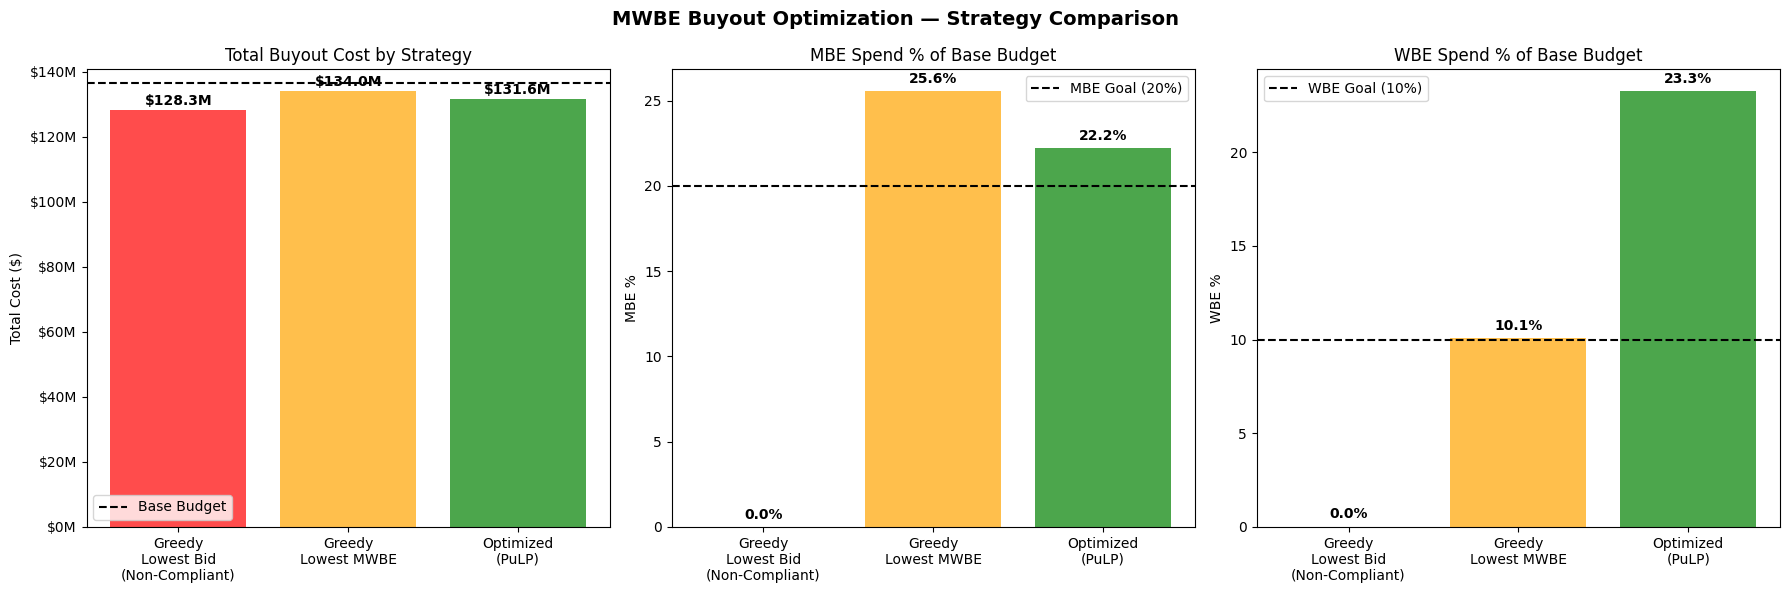

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Chart 1 - Total cost comparison across scenarios
scenarios = ["Greedy\nLowest Bid\n(Non-Compliant)", "Greedy\nLowest MWBE", "Optimized\n(PuLP)"]
costs = [s1_total, s2_total, pulp.value(prob.objective)]
colors = ["red", "orange", "green"]

bars = axes[0].bar(scenarios, costs, color=colors, alpha=0.7)
axes[0].axhline(y=total_budget, color="black", linestyle="--", label="Base Budget")
axes[0].set_title("Total Buyout Cost by Strategy")
axes[0].set_ylabel("Total Cost ($)")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1e6:.0f}M"))
axes[0].legend()

# Add value labels on bars
for bar, cost in zip(bars, costs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500000,
                f"${cost/1e6:.1f}M", ha="center", va="bottom", fontweight="bold")

# Chart 2 - MBE compliance across scenarios
mbe_pcts = [s1_mbe/total_budget*100, s2_mbe/total_budget*100, mbe_total/total_budget*100]
bars2 = axes[1].bar(scenarios, mbe_pcts, color=colors, alpha=0.7)
axes[1].axhline(y=mbe_goal*100, color="black", linestyle="--", label="MBE Goal (20%)")
axes[1].set_title("MBE Spend % of Base Budget")
axes[1].set_ylabel("MBE %")
axes[1].legend()

# Add value labels
for bar, pct in zip(bars2, mbe_pcts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{pct:.1f}%", ha="center", va="bottom", fontweight="bold")

# Chart 3 - WBE compliance across scenarios
wbe_pcts = [s1_wbe/total_budget*100, s2_wbe/total_budget*100, wbe_total/total_budget*100]
bars3 = axes[2].bar(scenarios, wbe_pcts, color=colors, alpha=0.7)
axes[2].axhline(y=wbe_goal*100, color="black", linestyle="--", label="WBE Goal (10%)")
axes[2].set_title("WBE Spend % of Base Budget")
axes[2].set_ylabel("WBE %")
axes[2].legend()

# Add value labels
for bar, pct in zip(bars3, wbe_pcts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{pct:.1f}%", ha="center", va="bottom", fontweight="bold")

plt.suptitle("MWBE Buyout Optimization — Strategy Comparison",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## Summary & Conclusions

### What This Model Demonstrates
This proof of concept demonstrates that MWBE subcontractor buyout
optimization is a mathematically solvable problem — and that manual
greedy selection strategies leave meaningful profit on the table
on every project.

### The Three Strategy Comparison
The comparison across three strategies produced a clear and
quantified finding:

| Strategy | Total Cost | Compliant |
|---|---|---|
| Greedy Lowest Bid | 128,259,032 | NO |
| Greedy Lowest MWBE | 133,980,524 | YES |
| Optimized (PuLP) | 131,621,927 | YES |

The optimizer is the only strategy that is both compliant and
cost efficient — saving 2,358,596 vs the greedy MWBE approach
on a single project.

### The Most Important Finding
Mathematical optimization found a non-obvious solution that no
greedy algorithm could guarantee — concentrating WBE spend in
the Concrete trade to satisfy the full WBE goal in a single award,
freeing other trades to select cheaper Non-MWBE subcontractors.
This counterintuitive allocation produced a lower total cost despite
a higher WBE percentage than the greedy approach.

### Business Case
On a single 500,000 GSF project the optimizer saves 2,358,596
vs manual greedy selection. Across a portfolio of multiple projects
per year this represents a significant and repeatable source of
additional profit — without sacrificing MWBE compliance or
subcontractor relationships. Beyond cost savings the model provides
full audit trail transparency for MWBE compliance reporting to
city agencies.

### Future Development
A Streamlit interactive dashboard would allow estimators to lock
in preferred subcontractors based on relationship history — the
model reoptimizes remaining trades automatically and displays the
cost premium of each preference decision. This would bring the
optimization model into the daily estimating workflow as a
practical decision support tool.

### Important Disclaimer
This model was built on synthetic bid data calibrated to real NYC
construction market rates. All findings should be validated against
real historical bid data before informing business decisions. The
model is intended as a proof of concept demonstrating the methodology
and analytical approach — not as a production buyout management tool.